# Probability Distributions -- Expected Value and the Tails You'll See

**Goal:** Choose the right distribution family for your security data, compute expected values safely, and understand why tail choice changes everything.

## Why distribution choice matters

Cyber risk quantification almost always decomposes into **frequency x severity**: how often does the bad thing happen, and how bad is it each time? The annual loss expectation (ALE) is the product of these two expected values, but the *shape* of each distribution determines what happens at the 95th percentile and beyond -- and that tail is where budgets break and executives lose sleep.

Fitting the wrong distribution is not a minor technical error. A normal model on breach costs will tell you the 95th-percentile loss is perhaps 2x the mean. A lognormal model might say 5x. A Pareto model might say 20x. The decision -- how much insurance to buy, how much to invest in controls -- changes by an order of magnitude depending on which family you choose.

This notebook walks through the distributions that matter for security-risk modelling and shows why the choice is consequential.

## Setup

We use `decision-security`'s `synth` module for sampling and `mixture` for combining distributions.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample, mixture

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"


## Expected Value and its Limits

The expected value $\mathbb{E}[X]$ is the probability-weighted average outcome. Linearity of expectation -- $\mathbb{E}[aX + bY] = a\mathbb{E}[X] + b\mathbb{E}[Y]$ -- holds regardless of dependence and is the workhorse behind ALE calculations:

$$\mathbb{E}[\text{loss}] = \mathbb{E}[\text{freq}] \times \mathbb{E}[\text{sev}]$$

If average loss per incident is $\mathbb{E}[X]$ and you expect $\lambda$ incidents, the expected aggregate loss is $\lambda \cdot \mathbb{E}[X]$.

But EV is a *center* measure. It tells you nothing about tail risk. Two portfolios can have the same EV and wildly different 95th percentiles. In security, decisions are usually about surviving the bad tail, not optimizing the average. Always pair EV with quantile estimates.

The catch: linearity applies to expectations, not to quantiles or tail measures. $p_{95}(X + Y) \neq p_{95}(X) + p_{95}(Y)$ unless the variables are perfectly correlated. This is why Monte Carlo simulation (Part 0.3) matters -- you can't shortcut tail calculations with algebra alone.

> **Note:** Linearity of expectation holds even for dependent random variables. But the *variance* of the sum does depend on correlation -- which matters for Monte Carlo modeling in Part 0.3.

In [10]:
X = np.random.default_rng(42).normal(loc=100, scale=25, size=50_000)

Y = 2 * X + 5

ev_direct = Y.mean()
ev_linear = 2 * X.mean() + 5

print(f"E[2X + 5]  (direct)  = {ev_direct:,.2f}")
print(f"2*E[X] + 5 (linear)  = {ev_linear:,.2f}")
print(f"Difference           = {abs(ev_direct - ev_linear):.6f}")

E[2X + 5]  (direct)  = 204.97
2*E[X] + 5 (linear)  = 204.97
Difference           = 0.000000


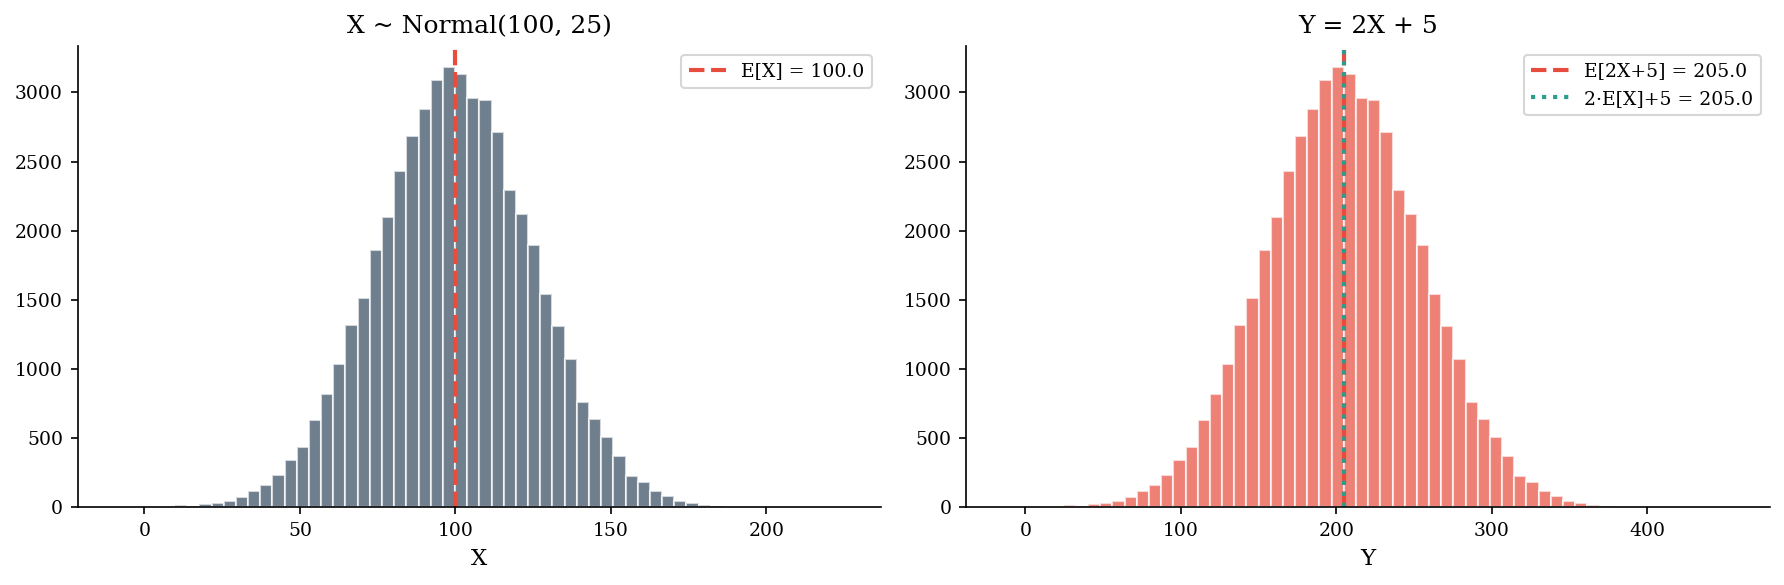

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X, bins=60, alpha=0.7, color=DARK_BG, edgecolor="white")
axes[0].axvline(X.mean(), color=ACCENT, linestyle="--", linewidth=2, label=f"E[X] = {X.mean():.1f}")
axes[0].set_title("X ~ Normal(100, 25)")
axes[0].set_xlabel("X")
axes[0].legend()

axes[1].hist(Y, bins=60, alpha=0.7, color=ACCENT, edgecolor="white")
axes[1].axvline(Y.mean(), color=ACCENT, linestyle="--", linewidth=2, label=f"E[2X+5] = {Y.mean():.1f}")
axes[1].axvline(2 * X.mean() + 5, color="#2a9d8f", linestyle=":", linewidth=2, label=f"2\u00b7E[X]+5 = {2*X.mean()+5:.1f}")
axes[1].set_title("Y = 2X + 5")
axes[1].set_xlabel("Y")
axes[1].legend()

plt.tight_layout()
plt.show()

## Frequency: Poisson vs Negative Binomial

The **Poisson distribution** models the count of events in a fixed window (incidents per quarter, breaches per year) when events occur independently at a constant rate $\lambda$. Its key property: mean equals variance ($\mathbb{E}[X] = \text{Var}(X) = \lambda$).

In practice, security event counts often exhibit **overdispersion** -- the variance exceeds the mean -- because the underlying rate is not constant. Threat campaigns cluster; vulnerability disclosures come in waves. The **negative binomial** distribution adds a dispersion parameter $k$, allowing variance to exceed the mean. If your observed variance-to-mean ratio is substantially above 1, negative binomial is the better fit.

A practical test: compute the sample mean and variance of your monthly incident counts. If $s^2 / \bar{x} > 1.5$, try negative binomial. If it is close to 1, Poisson suffices.

> **Note:** Ransomware campaigns illustrate overdispersion well. In quiet months you see zero or one event; when a new variant spreads, you might see a cluster of five in a single week. The negative binomial captures this "bursty" pattern that Poisson cannot.

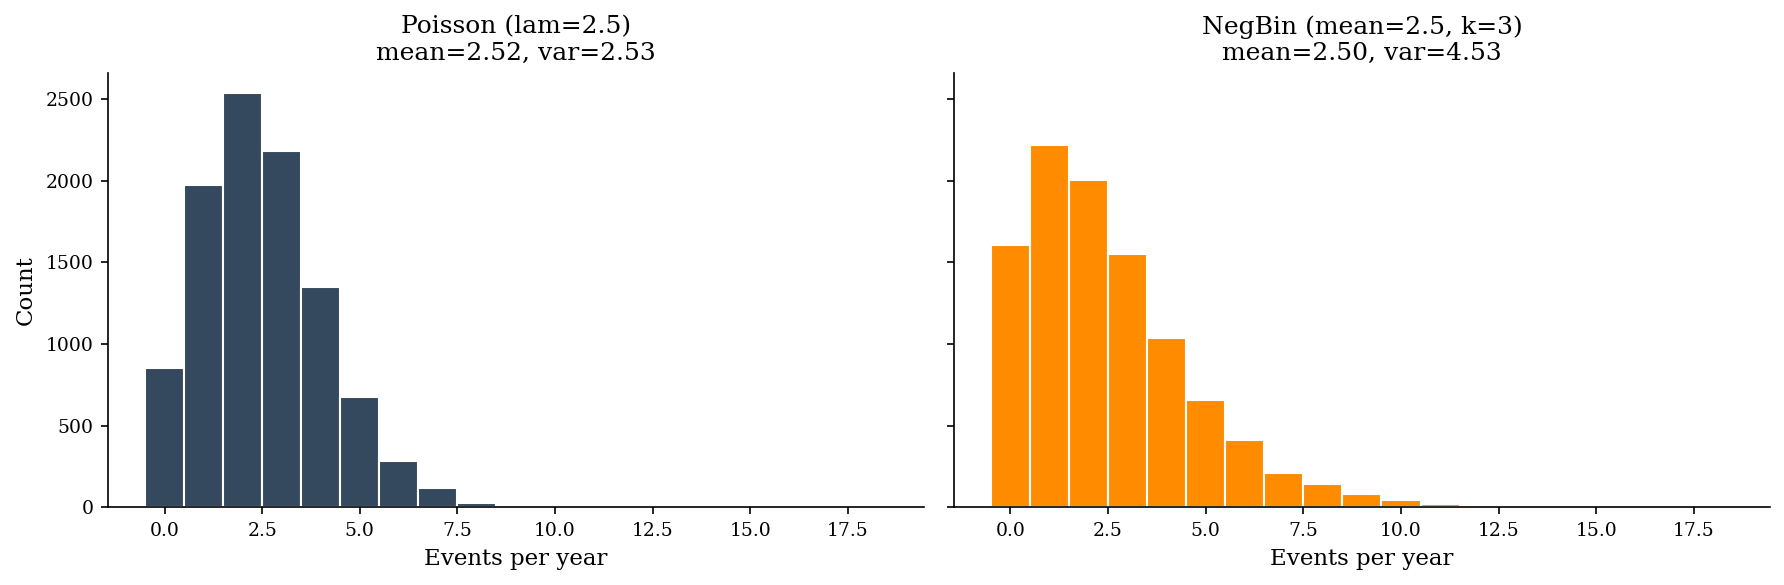

Poisson  p95 = 5
NegBin   p95 = 7


In [12]:
freq_pois   = sample('poisson', 10000, lam=2.5)
freq_negbin = sample('negbin',  10000, mean=2.5, k=3.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

bins = np.arange(0, 20)

axes[0].hist(freq_pois, bins=bins, align='left', color=DARK_BG, edgecolor='white')
axes[0].set_title(f'Poisson (lam=2.5)\nmean={freq_pois.mean():.2f}, var={freq_pois.var():.2f}')
axes[0].set_xlabel('Events per year')
axes[0].set_ylabel('Count')

axes[1].hist(freq_negbin, bins=bins, align='left', color='darkorange', edgecolor='white')
axes[1].set_title(f'NegBin (mean=2.5, k=3)\nmean={freq_negbin.mean():.2f}, var={freq_negbin.var():.2f}')
axes[1].set_xlabel('Events per year')

plt.tight_layout()
plt.show()

print(f"Poisson  p95 = {np.percentile(freq_pois, 95):.0f}")
print(f"NegBin   p95 = {np.percentile(freq_negbin, 95):.0f}")

## Severity: Lognormal vs Pareto

Both are right-skewed with long tails, but the Pareto tail is *much* heavier.
For the same median loss, a Pareto distribution produces extreme values far more often.

**Lognormal** (soft tail): the default starting point in cyber risk. It arises naturally when losses are the product of many multiplicative factors (scope of breach $\times$ records affected $\times$ cost-per-record $\times$ regulatory multiplier). The lognormal is parameterized by $\mu$ and $\sigma$ on the log scale: the median is $e^{\mu}$ and quantiles follow:

$$Q_p = \exp(\mu + \sigma \, z_p)$$

where $z_p$ is the standard normal quantile. Most breach cost data fits here. The log-transformed values are roughly normal, so the distribution has a well-behaved mean.

**Pareto** (hard tail): models the "power law" regime where a small number of events account for most of the total loss. Empirically, the largest cyber losses (nation-state attacks, massive data breaches) exhibit Pareto-like behavior. The key diagnostic is the tail index $\alpha$: when $\alpha \leq 2$, variance is infinite and sample means are unstable.

**When to choose which:** Use lognormal as the default for severity. Escalate to Pareto (or a generalized Pareto tail splice) when you have evidence of extreme tail weight -- for instance, when the top 5% of losses account for more than 50% of the total. Another diagnostic: if $p_{99}/p_{95}$ is much larger than $p_{95}/p_{90}$, you may be in Pareto territory.

The choice matters enormously: switching from lognormal to Pareto on the same data can double your p95 estimate.

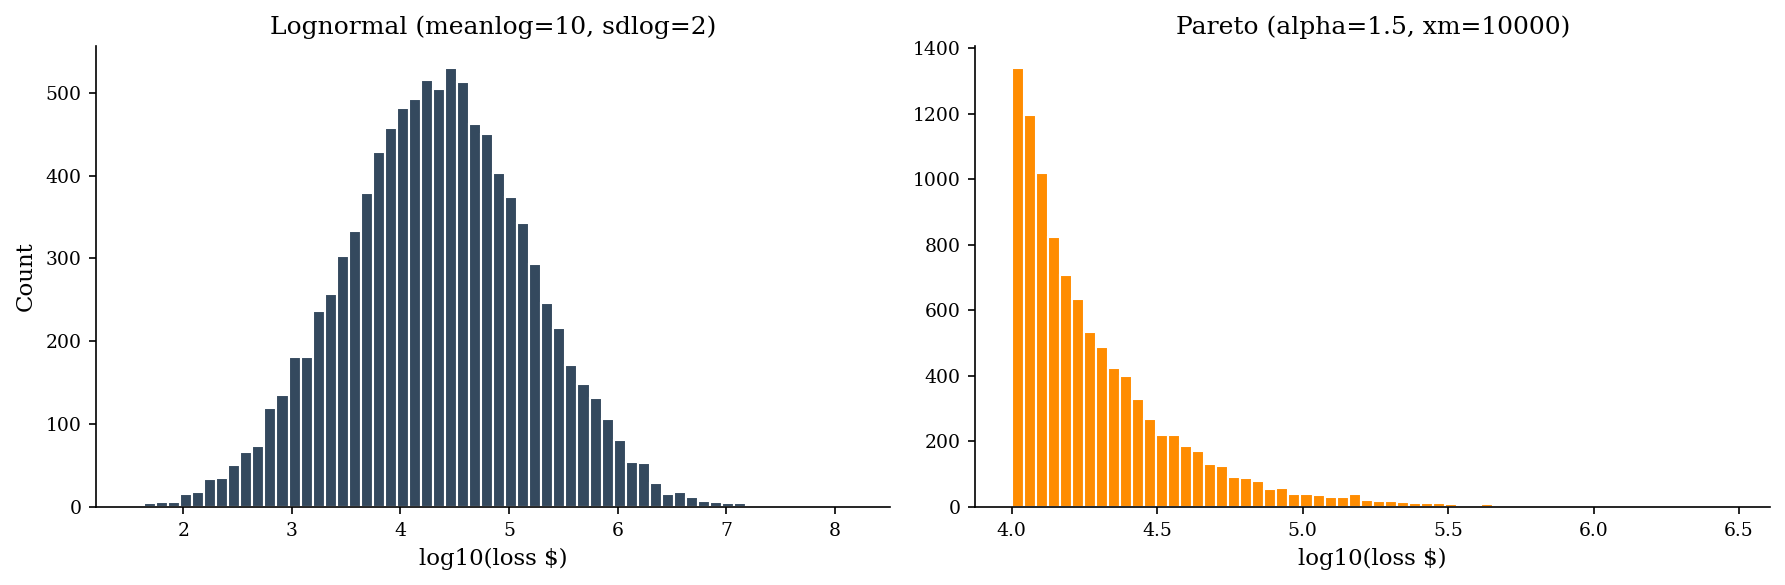

Lognormal   median=$        21,833   p95=$       586,355   p99=$     2,043,109
Pareto      median=$        15,917   p95=$        76,622   p99=$       248,973


In [13]:
sev_logn   = sample('lognormal', 10000, meanlog=10, sdlog=2)
sev_pareto = sample('pareto',    10000, alpha=1.5, xm=10000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.log10(sev_logn), bins=60, color=DARK_BG, edgecolor='white')
axes[0].set_title('Lognormal (meanlog=10, sdlog=2)')
axes[0].set_xlabel('log10(loss $)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log10(sev_pareto), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Pareto (alpha=1.5, xm=10000)')
axes[1].set_xlabel('log10(loss $)')

plt.tight_layout()
plt.show()

for label, arr in [('Lognormal', sev_logn), ('Pareto', sev_pareto)]:
    print(f"{label:10s}  median=${np.median(arr):>14,.0f}   "
          f"p95=${np.percentile(arr, 95):>14,.0f}   "
          f"p99=${np.percentile(arr, 99):>14,.0f}")

## Expert Elicitation: Lognormal from Two Quantiles

When historical data is sparse, you can calibrate a lognormal from expert-elicited quantiles. Experts rarely think in $\mu_{\log}$ and $\sigma_{\log}$. They say things like: "median loss is about \$50K, and it could go as high as \$2M in a bad case."

Ask the subject-matter expert: "What is the median loss?" and "What is a reasonable worst case -- the value exceeded only 5% of the time?" These give you two equations:

$$\text{median} = e^{\mu}, \quad Q_{0.95} = \exp(\mu + 1.645\,\sigma)$$

Solving:

$$\mu = \ln(\text{median}), \quad \sigma = \frac{\ln(Q_{0.95}) - \ln(\text{median})}{1.645}$$

This two-point calibration is the backbone of FAIR-style risk quantification and gives you a full distributional model from minimal input. The `from_quantiles` option below takes two quantile-value pairs and back-solves for the lognormal parameters automatically.

> **Tip:** Train your experts to think in orders of magnitude. "Is the worst case 3x the median or 30x?" maps directly to $\sigma$ -- a ratio of 3 implies $\sigma \approx 0.67$; a ratio of 30 implies $\sigma \approx 2.07$.

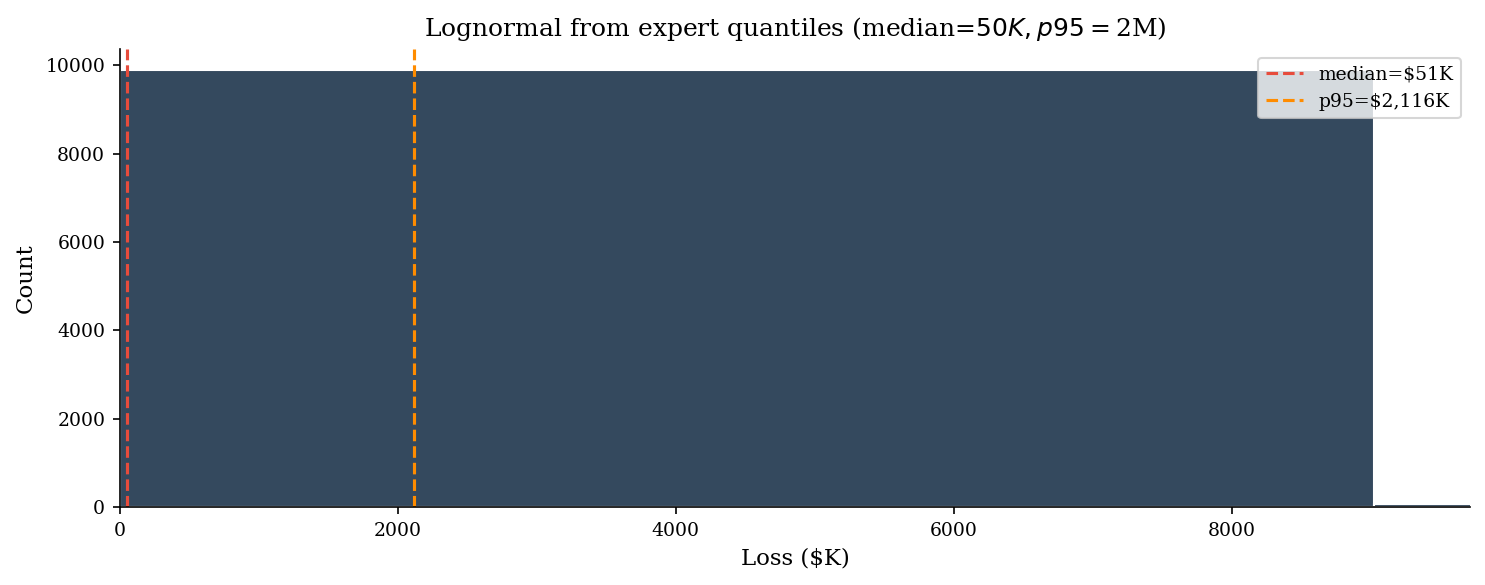

In [14]:
sev_expert = sample(
    'lognormal', 10000,
    from_quantiles=True,
    x1=50_000,  p1=0.5,
    x2=2_000_000, p2=0.95,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sev_expert / 1e3, bins=100, color=DARK_BG, edgecolor='white')
ax.axvline(np.median(sev_expert) / 1e3, color=ACCENT, ls='--', label=f'median=${np.median(sev_expert)/1e3:,.0f}K')
ax.axvline(np.percentile(sev_expert, 95) / 1e3, color='darkorange', ls='--',
           label=f'p95=${np.percentile(sev_expert, 95)/1e3:,.0f}K')
ax.set_xlabel('Loss ($K)')
ax.set_ylabel('Count')
ax.set_title('Lognormal from expert quantiles (median=$50K, p95=$2M)')
ax.set_xlim(0, np.percentile(sev_expert, 99) / 1e3)
ax.legend()
plt.tight_layout()
plt.show()

## Mixtures: Bimodal Breach Data

Real breach-cost data often looks bimodal: a large cluster of routine incidents (credential stuffing, single-endpoint malware, small data exposure, contained quickly) and a small cluster of catastrophic events (mass data exfiltration, ransomware with extended downtime, major litigation, regulatory action). No single lognormal fits both modes well.

A **mixture model** -- say, 90% lognormal($\mu_1, \sigma_1$) + 10% lognormal($\mu_2, \sigma_2$) -- captures this structure. The mixture inflates the tail beyond what either component alone would produce. In practice, even a two-component mixture substantially improves p95 estimates compared to a single fitted distribution.

A single lognormal has one mode. A mixture model combines two (or more) component distributions with mixing weights. The result is a distribution that can have multiple peaks, matching the "mostly small, occasionally enormous" pattern that shows up in empirical breach data.

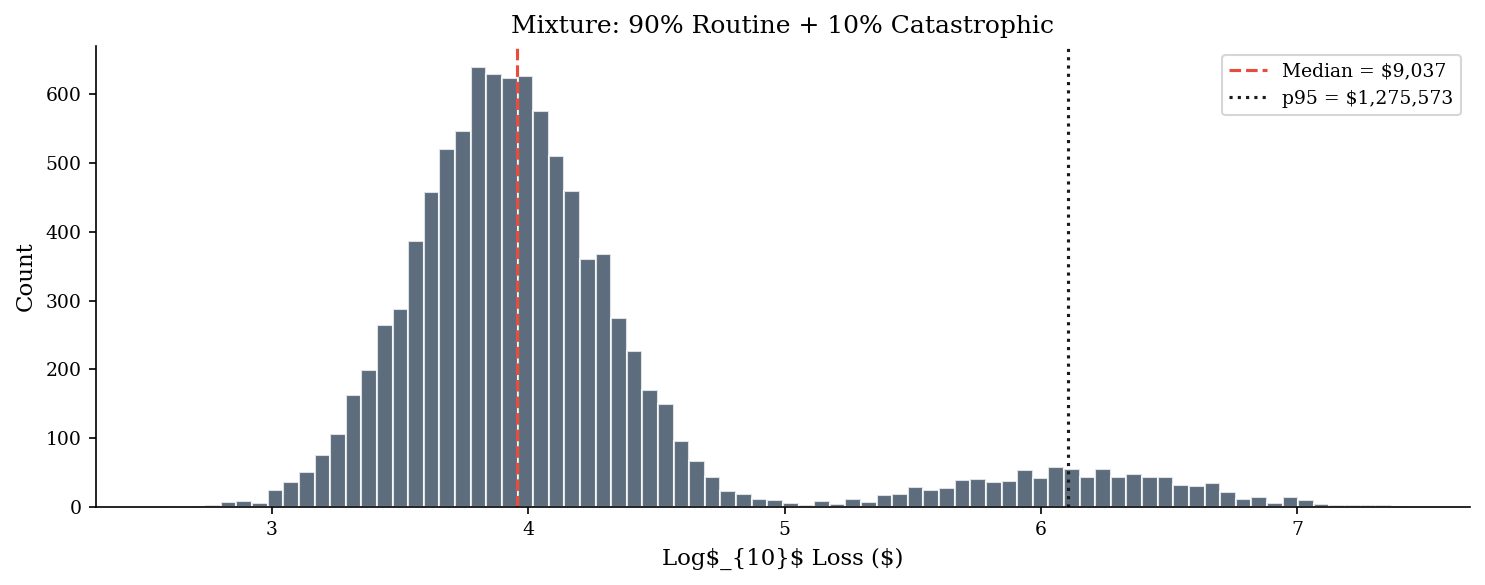

In [15]:
rng = make_rng(42)

mixed = mixture(
    components=[
        ('lognormal', {'meanlog': 9, 'sdlog': 0.8}),
        ('lognormal', {'meanlog': 14, 'sdlog': 1.0}),
    ],
    weights=[0.9, 0.1],
    size=10000,
    rng=rng,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(mixed[mixed > 0]), bins=80, color=DARK_BG, edgecolor="white", alpha=0.8)
ax.set_xlabel("Log$_{10}$ Loss ($)")
ax.set_ylabel("Count")
ax.set_title("Mixture: 90% Routine + 10% Catastrophic")
ax.axvline(np.log10(np.median(mixed[mixed > 0])), color=ACCENT, linestyle="--",
           linewidth=1.5, label=f"Median = ${np.median(mixed[mixed > 0]):,.0f}")
ax.axvline(np.log10(np.percentile(mixed[mixed > 0], 95)), color=PRIMARY, linestyle=":",
           linewidth=1.5, label=f"p95 = ${np.percentile(mixed[mixed > 0], 95):,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## Model Selection Cheat Sheet

| Data type | Default family | Upgrade when... |
|---|---|---|
| Event counts (stable rate) | **Poisson** | Overdispersion ($s^2/\bar{x} > 1.5$) --> negative binomial |
| Event counts (many zeros) | **Zero-inflated Poisson** | Zero-inflated negative binomial |
| Loss per event | **Lognormal** | Extreme tail weight --> Pareto or GPD splice |
| Proportions | **Beta** | N/A (use Wilson CI for inference) |
| Bimodal losses | **Lognormal mixture** | Formal mixture model with EM |
| Overdispersed counts | **Negative Binomial** | Extra dispersion parameter $k$ lets the tail stretch beyond Poisson |

## Common Traps

1. **Normal on skewed data.** The normal distribution allows negative values and has thin tails. Applying it to loss data truncates the tail and produces nonsensical negative-loss scenarios. A normal fit will understate the tail *and* generate impossible negative losses. Always use a right-skewed distribution (lognormal, gamma, Pareto) for positive-only, skewed severity quantities.

2. **Estimating EV from too few tail samples.** With 30 observations you can estimate the median reliably but the 95th percentile poorly. With 1,000 draws, your p99 estimate is based on roughly 10 observations. If you have fewer than ~100 data points, treat tail estimates as highly uncertain and report wide credible intervals. For stable tail estimates, use at least 10,000 draws -- and even then, treat extreme quantiles (p99.9) with skepticism.

3. **Ignoring zero-inflation.** Many security count series have excess zeros (months with no incidents of a particular type). A Poisson with a low $\lambda$ already handles some zero mass, but if the zero mass is *larger* than Poisson predicts, standard Poisson or negative binomial will underfit the zero mass and overfit the positive counts. Test for zero-inflation and use ZIP/ZINB models if warranted, or a mixture with a point mass at zero.

## Bayesian Preview: Flipping the Probability Tree

Raiffa (1968) introduced one of the most intuitive explanations of Bayes' theorem by showing how to mechanically "flip" a probability tree. The forward tree starts with the state of the world (intrusion or benign) and branches to the observable evidence (alert fires or not). The flipped tree reverses the order: it starts with the evidence you actually observe (alert fired) and branches to the posterior probability of each state.

The flipping procedure is mechanical: compute each path's joint probability as the product of its branch probabilities, sum the paths that lead to the same evidence outcome, and divide each joint by that sum. The result is the posterior -- no formula memorization required.

**Security scenario:** An IDS alert fires. You need to decide if this is a real intrusion or a false positive.

- **Prior:** 2% of alerts correspond to real intrusions (base rate from historical data).
- **Detection:** If it's a real intrusion, the IDS fires 90% of the time (sensitivity).
- **False alarm:** If it's benign, the IDS still fires 5% of the time (false positive rate).

The forward tree gives: $P(\text{alert} \mid \text{intrusion}) = 0.90$, $P(\text{alert} \mid \text{benign}) = 0.05$.
Flipping the tree gives: $P(\text{intrusion} \mid \text{alert}) = ?$

Most analysts intuitively guess 50--80%. The Bayesian answer is approximately 27% -- because the 98% base rate of benign traffic, even with only a 5% false alarm rate, generates far more false alerts than the 2% intrusion rate generates true ones.

This calculation has direct operational implications. It explains why even high-quality detection systems produce alert volumes dominated by false positives, why SOC teams develop "alert fatigue," and why base-rate awareness is the single most important statistical concept for anyone triaging security events.

In [16]:
# Raiffa's tree-flipping: IDS alert scenario
# Forward tree: P(alert | state) -> Flipped tree: P(state | alert)

p_intrusion = 0.02       # prior: 2% of alerts are real
p_benign = 1 - p_intrusion

p_alert_given_intrusion = 0.90   # sensitivity
p_alert_given_benign = 0.05      # false positive rate

# Joint probabilities (forward tree paths)
p_intrusion_and_alert = p_intrusion * p_alert_given_intrusion
p_benign_and_alert = p_benign * p_alert_given_benign

# Marginal probability of alert
p_alert = p_intrusion_and_alert + p_benign_and_alert

# Flip the tree: posterior
p_intrusion_given_alert = p_intrusion_and_alert / p_alert

print("=== Forward Tree (data order) ===")
print(f"  P(intrusion AND alert) = {p_intrusion:.2f} x {p_alert_given_intrusion:.2f} = {p_intrusion_and_alert:.4f}")
print(f"  P(benign AND alert)    = {p_benign:.2f} x {p_alert_given_benign:.2f} = {p_benign_and_alert:.4f}")
print(f"  P(alert)               = {p_alert:.4f}")
print()
print("=== Flipped Tree (what we need) ===")
print(f"  P(intrusion | alert)   = {p_intrusion_and_alert:.4f} / {p_alert:.4f} = {p_intrusion_given_alert:.1%}")
print(f"  P(benign | alert)      = {1 - p_intrusion_given_alert:.1%}")
print()
print(f"Even with 90% sensitivity, only {p_intrusion_given_alert:.1%} of alerts are real intrusions.")
print("The base rate dominates. This is why SOC teams drown in false positives.")

=== Forward Tree (data order) ===
  P(intrusion AND alert) = 0.02 x 0.90 = 0.0180
  P(benign AND alert)    = 0.98 x 0.05 = 0.0490
  P(alert)               = 0.0670

=== Flipped Tree (what we need) ===
  P(intrusion | alert)   = 0.0180 / 0.0670 = 26.9%
  P(benign | alert)      = 73.1%

Even with 90% sensitivity, only 26.9% of alerts are real intrusions.
The base rate dominates. This is why SOC teams drown in false positives.
